In [22]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

df = pd.read_csv("../../Week 01/Day 5/sales_cleaned.csv")

df


,sale_id,customer_name,product,category,quantity,amount,city,payment_method
0,1,Anil,Laptop,Electronics,1,55000.0,Bengaluru,UPI
1,4,Ananya,Laptop,Electronics,1,65000.0,Delhi,UPI
2,9,Divya,Laptop,Electronics,1,75000.0,Bengaluru,UPI


In [23]:
print("Dataset Shape:", df.shape)

print("\nData Types:")
print(df.dtypes)

print("\nNull Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:")
print(df.duplicated().sum())

Dataset Shape: (3, 8)

Data Types:
sale_id             int64
customer_name         str
product               str
category              str
quantity            int64
amount            float64
city                  str
payment_method        str
dtype: object

Null Values:
sale_id           0
customer_name     0
product           0
category          0
quantity          0
amount            0
city              0
payment_method    0
dtype: int64

Duplicate Rows:
0


In [24]:
summary_statistics = df.describe()

summary_statistics

,sale_id,quantity,amount
count,3.000000,3.0,3.0
mean,4.666667,1.0,65000.0
std,4.041452,0.0,10000.0
min,1.000000,1.0,55000.0
25%,2.500000,1.0,60000.0
50%,4.000000,1.0,65000.0
75%,6.500000,1.0,70000.0
max,9.000000,1.0,75000.0


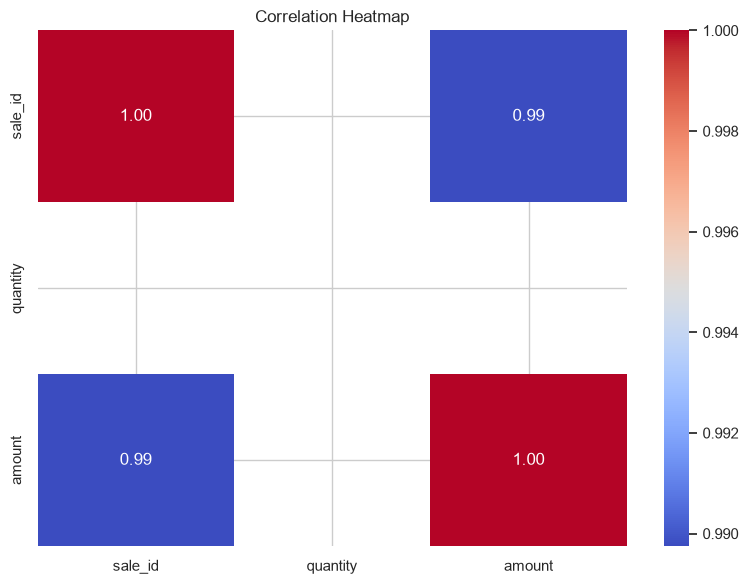

In [25]:
numeric_columns = df.select_dtypes(include="number").columns

correlation_matrix = df[numeric_columns].corr()

plt.figure(figsize=(8, 6))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")
plt.tight_layout()

plt.show()

In [26]:
print("BUSINESS INSIGHTS")

print(
    "1. The average sales amount is ₹65,000, "
    "indicating a relatively high average transaction value."
)

print(
    "2. Sales amounts range from ₹55,000 to ₹75,000, "
    "showing a ₹20,000 difference between the lowest and highest transaction."
)

print(
    "3. The current dataset is concentrated in one product category."
)

print(
    "4. UPI is the payment method used in all recorded transactions."
)

print(
    "5. Every recorded transaction has a quantity of 1, "
    "so the current sample does not show variation in quantity."
)

BUSINESS INSIGHTS
1. The average sales amount is ₹65,000, indicating a relatively high average transaction value.
2. Sales amounts range from ₹55,000 to ₹75,000, showing a ₹20,000 difference between the lowest and highest transaction.
3. The current dataset is concentrated in one product category.
4. UPI is the payment method used in all recorded transactions.
5. Every recorded transaction has a quantity of 1, so the current sample does not show variation in quantity.


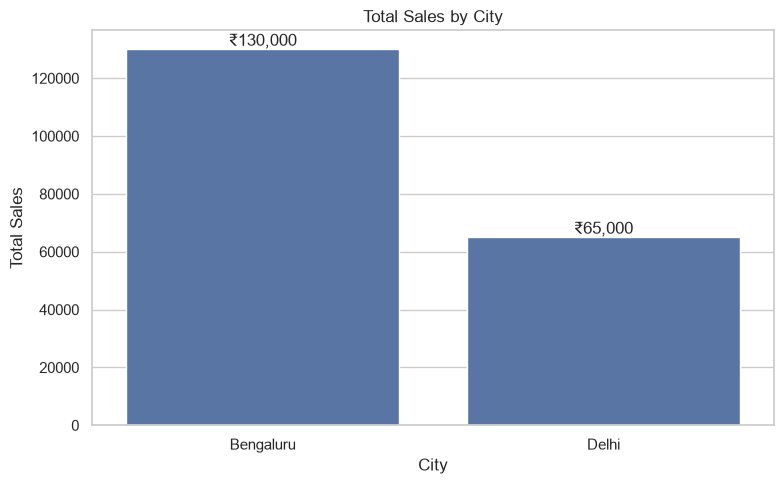

In [27]:
city_sales = df.groupby("city", as_index=False)["amount"].sum()

plt.figure(figsize=(8, 5))

ax = sns.barplot(
    data=city_sales,
    x="city",
    y="amount"
)

plt.title("Total Sales by City")
plt.xlabel("City")
plt.ylabel("Total Sales")

for container in ax.containers:
    ax.bar_label(
        container,
        labels=[f"₹{value:,.0f}" for value in container.datavalues]
    )

plt.tight_layout()
plt.show()

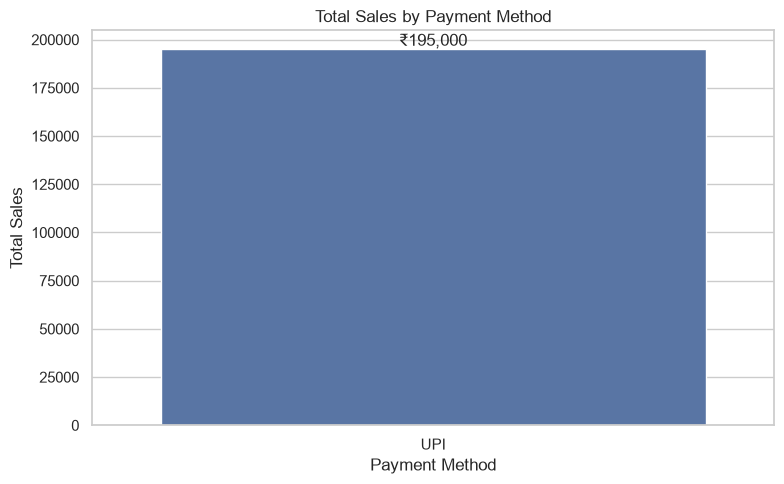

In [28]:
payment_sales = df.groupby(
    "payment_method",
    as_index=False
)["amount"].sum()

plt.figure(figsize=(8, 5))

ax = sns.barplot(
    data=payment_sales,
    x="payment_method",
    y="amount"
)

plt.title("Total Sales by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Total Sales")

for container in ax.containers:
    ax.bar_label(
        container,
        labels=[f"₹{value:,.0f}" for value in container.datavalues]
    )

plt.tight_layout()
plt.show()